<a href="https://colab.research.google.com/github/cs24dse007-boop/CSL701-CS04-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Omkar M.Bhalekar
Roll No.:CS04
Batch:cs1

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


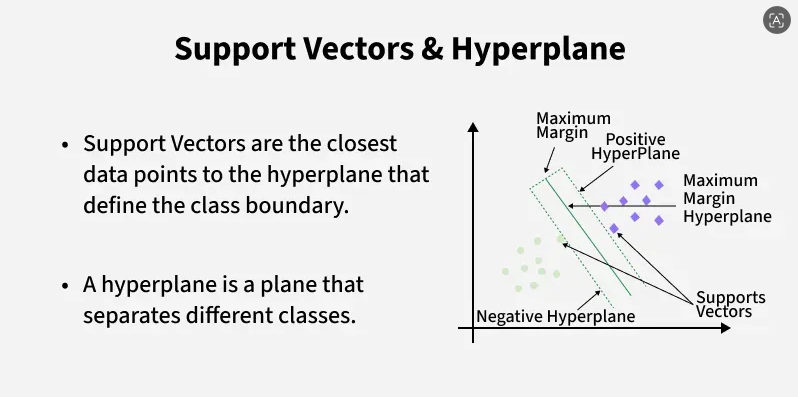
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
# Import required libraries
import pandas as pd
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Convert the dataset into a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df["target"] = iris.target

# Display the first 5 rows
print(df.head())


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


# Task 2: Explore the Dataset

In [2]:
# Display the first 5 rows
print("First 5 rows:")
print(df.head())

# Display the last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Check the number of rows and columns
print("\nDataset shape:")
print(df.shape)

# Get information about the dataset
print("\nDataset information:")
print(df.info())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Display statistical summary
print("\nStatistical summary:")
print(df.describe())

# Check the target class distribution
print("\nTarget class distribution:")
print(df["target"].value_counts())


First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Last 5 rows:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
145                6.7               3.0                5.2               2.3   
146                6.3               2.5                5.0               1.9   
147                6.5               3.0                5.2               2.0   
148                6.2               3.4                5.4               2.3   
149                5

# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Select features
X = df[iris.feature_names]

# Select target
y = df["target"]

# Display the features
print("Features (X):")
print(X.head())

# Display the target
print("\nTarget (y):")
print(y.head())

# Check their shapes
print("\nFeatures shape:", X.shape)
print("Target shape:", y.shape)


Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Features shape: (150, 4)
Target shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create a StandardScaler
scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Display the shapes
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)


Training data shape: (120, 4)
Testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
from sklearn.svm import SVC

# Create a Linear SVM model
svm_model = SVC(kernel="linear", random_state=42)

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions on the test data
y_pred = svm_model.predict(X_test_scaled)

# Display predictions
print("Predictions:")
print(y_pred)


Predictions:
[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 1 1 0 2 0]


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Generate classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=iris.target_names
))


Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

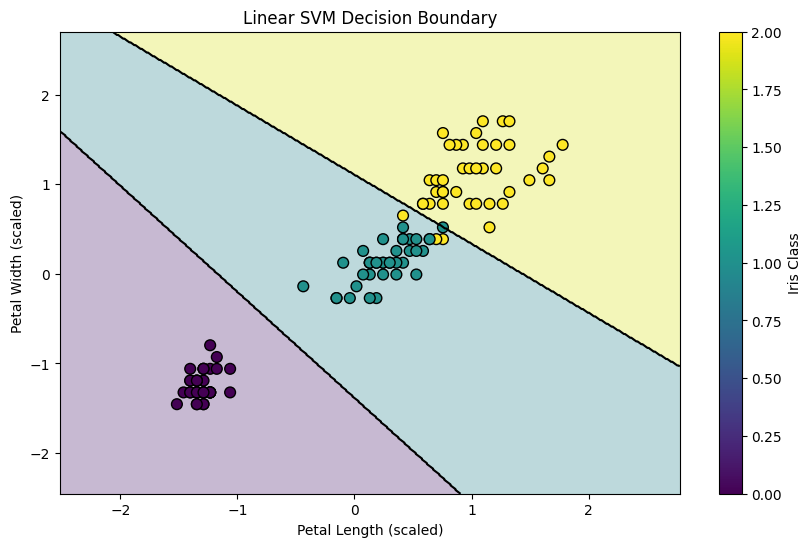

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Create the 2-D dataset
X_2d = df[["petal length (cm)", "petal width (cm)"]]
y_2d = df["target"]

# 2. Split the data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# 3. Scale the data
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# 4. Train Linear SVM
svm_2d = SVC(kernel="linear", random_state=42)
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# 5. Create a mesh grid for the decision boundary
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict the class for every point in the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

# Plot training data points
scatter = plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    cmap="viridis",
    edgecolor="black",
    s=60
)

# Plot the SVM decision boundary
plt.contour(
    xx, yy, Z,
    levels=[0.5, 1.5],
    colors="black",
    linewidths=1.5
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Linear SVM Decision Boundary")
plt.colorbar(scatter, label="Iris Class")
plt.show()


# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

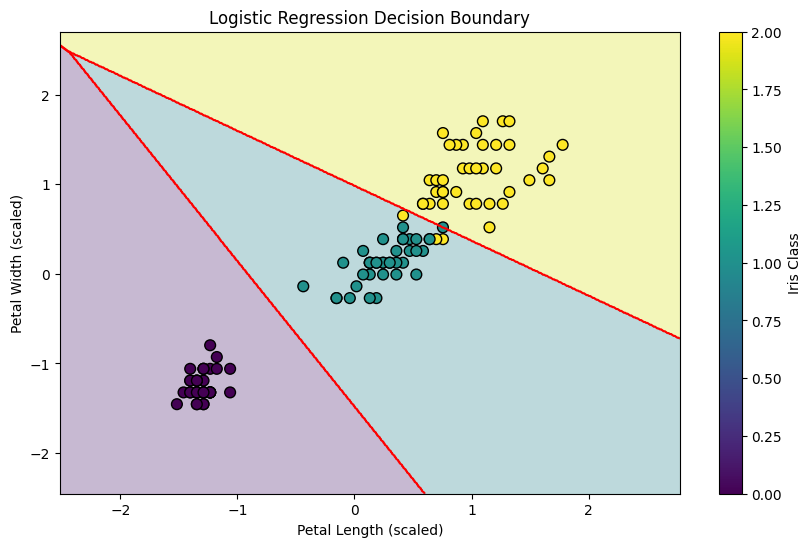

In [8]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

# 1. Create and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_2d_scaled, y_train_2d)

# 2. Make predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)

# 3. Create a mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# 4. Predict classes for the mesh grid
Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot the Logistic Regression decision boundary
plt.figure(figsize=(10, 6))

# Decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="viridis"
)

# Training data points
scatter = plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    cmap="viridis",
    edgecolor="black",
    s=60
)

# Decision boundaries
plt.contour(
    xx,
    yy,
    Z,
    levels=[0.5, 1.5],
    colors="red",
    linewidths=1.5
)

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.colorbar(scatter, label="Iris Class")
plt.show()


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

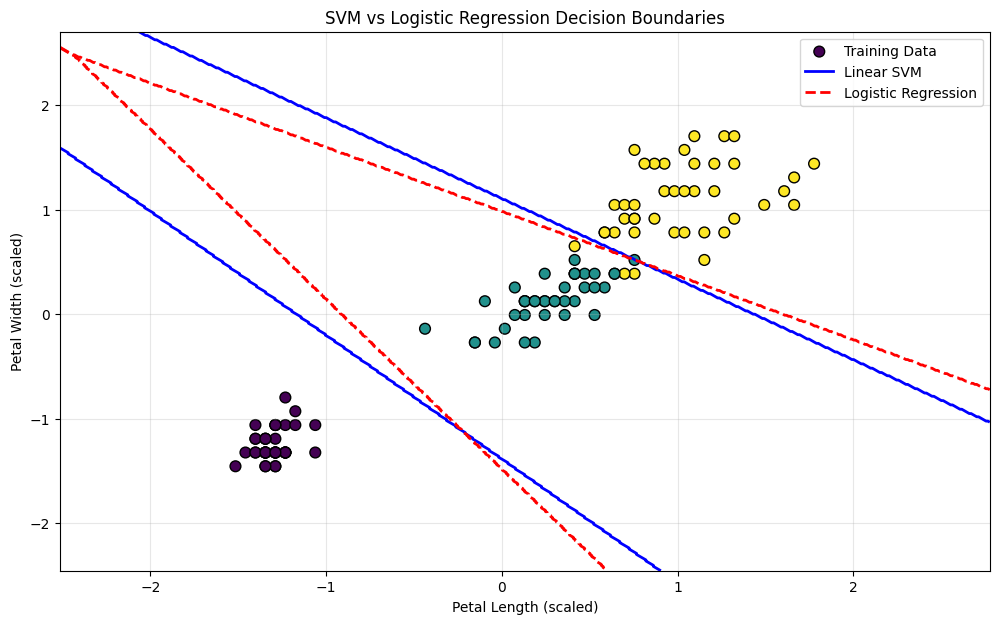

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Create a mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1
y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

grid = np.c_[xx.ravel(), yy.ravel()]

# Predictions from both models
Z_svm = svm_2d.predict(grid).reshape(xx.shape)
Z_logistic = logistic_model.predict(grid).reshape(xx.shape)

# Create the plot
plt.figure(figsize=(12, 7))

# Plot data points
plt.scatter(
    X_train_2d_scaled[:, 0],
    X_train_2d_scaled[:, 1],
    c=y_train_2d,
    cmap="viridis",
    edgecolor="black",
    s=60,
    label="Training Data"
)

# Plot SVM decision boundaries
plt.contour(
    xx,
    yy,
    Z_svm,
    levels=[0.5, 1.5],
    colors="blue",
    linewidths=2,
    linestyles="solid"
)

# Plot Logistic Regression decision boundaries
plt.contour(
    xx,
    yy,
    Z_logistic,
    levels=[0.5, 1.5],
    colors="red",
    linewidths=2,
    linestyles="dashed"
)

# Custom legend
plt.plot([], [], color="blue", linewidth=2, label="Linear SVM")
plt.plot([], [], color="red", linewidth=2, linestyle="--",
         label="Logistic Regression")

plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")
plt.title("SVM vs Logistic Regression Decision Boundaries")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [10]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# Make predictions
y_pred_svm_2d = svm_2d.predict(X_test_2d_scaled)
y_pred_logistic_2d = logistic_model.predict(X_test_2d_scaled)

# --------------------------------------------------
# Accuracy
# --------------------------------------------------

svm_accuracy = accuracy_score(y_test_2d, y_pred_svm_2d)
logistic_accuracy = accuracy_score(y_test_2d, y_pred_logistic_2d)

print("Accuracy Comparison")
print("-------------------")
print(f"Linear SVM:          {svm_accuracy:.4f}")
print(f"Logistic Regression: {logistic_accuracy:.4f}")


# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------

svm_cm = confusion_matrix(y_test_2d, y_pred_svm_2d)
logistic_cm = confusion_matrix(y_test_2d, y_pred_logistic_2d)

print("\nLinear SVM - Confusion Matrix:")
print(svm_cm)

print("\nLogistic Regression - Confusion Matrix:")
print(logistic_cm)


# --------------------------------------------------
# Classification Report
# --------------------------------------------------

print("\nLinear SVM - Classification Report:")
print(
    classification_report(
        y_test_2d,
        y_pred_svm_2d,
        target_names=iris.target_names
    )
)

print("\nLogistic Regression - Classification Report:")
print(
    classification_report(
        y_test_2d,
        y_pred_logistic_2d,
        target_names=iris.target_names
    )
)


Accuracy Comparison
-------------------
Linear SVM:          0.9333
Logistic Regression: 0.9333

Linear SVM - Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression - Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Linear SVM - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


Logistic Regression - Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was preprocessed and standardized before training the model.

A **Linear SVM** was implemented and its decision boundary was visualized along with the support vectors. A normal linear classification boundary using **Logistic Regression** was also visualized for comparison.